# Synthetic data

This notebook generates synthetic interval data from a number of random processes (see `src/synthetic.py`). The synthetic intervals are stored to `data/synthetic-intervals.json` and used in this notebook and other notebooks to create various figures.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../')
from src.synthetic import *
from src.utils import load_synthetic_intervals, savefig

# If true the data will be refreshed and written to disk
REFRESH_DATA = True

## Generate synthetic datasets

In [2]:
kws = dict(size=1500, rng=0)
data = []

unif_quant_kws = dict(unit=0.2, low=1, high=11, noise_amount=0.1, **kws)
data.append(dict(
    name="uniform quantal",
    generator="uniform_quantal_intervals",
    params=unif_quant_kws,
    intervals = uniform_quantal_intervals(**unif_quant_kws).tolist()
))

geom_quant_kws = dict(unit=0.2, p=0.5, noise_amount=0.1, **kws)
data.append(dict(
    name="geometric quantal",
    generator="geometric_quantal_intervals",
    params=dict(**geom_quant_kws),
    intervals = geometric_quantal_intervals(**geom_quant_kws).tolist()
))

unif_kws = dict(low=.2, high=2, **kws)
data.append(dict(
    name="uniform",
    generator="uniform_intervals",
    params=dict(**unif_kws),
    intervals = uniform_intervals(**unif_kws).tolist()
))

norm_kws = dict(loc=1, scale=.5, **kws)
data.append(dict(
    name="normal",
    generator="normal_intervals",
    params=dict(**norm_kws),
    intervals = normal_intervals(**norm_kws).tolist()
))

iso_kws = dict(loc=1, scale=.05, **kws)
data.append(dict(
    name="isochrony", 
    generator="normal_intervals",
    params=dict(**iso_kws),
    intervals = normal_intervals(**iso_kws).tolist()
))

clappy_kws = dict(noise_amount=0.1, **kws)
data.append(dict(
    name='repeated',
    generator='clappy_music',
    params=dict(**clappy_kws),
    intervals = clappy_music(**clappy_kws).tolist()
))

In [3]:
# Write to a single json file 
if REFRESH_DATA:
	with open('../data/synthetic-intervals.json', 'w') as f:
		json.dump(data, f)

## Show densities

In [4]:
datasets = load_synthetic_intervals()
print([d["name"] for d in datasets])

['uniform quantal', 'geometric quantal', 'uniform', 'normal', 'isochrony', 'repeated']


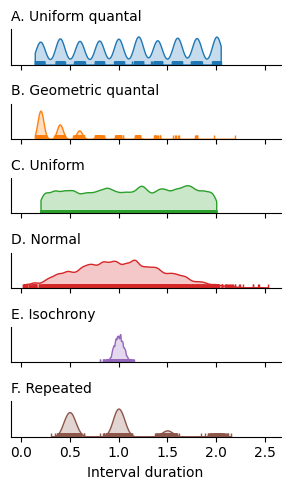

In [9]:
def show_interval_dist(intervals, title=None, ax=None, color=None):
	if ax is None: ax = plt.gca()
	sns.kdeplot(intervals, fill=True, bw_adjust=1/3, ax=ax, cut=0, color=color)
	sns.rugplot(intervals, ax=ax, height=.1, color=color)
	sns.despine(ax=ax)
	ax.set_ylabel('')
	ax.set_yticks([])
	if title:
		ax.set_title(title, ha='left', x=0, fontsize=10)

kws = dict(size=1000, rng=0)
unif_quantal = uniform_quantal_intervals(**kws, high=11)
geom_quantal = geometric_quantal_intervals(**kws)
unif = uniform_intervals(**kws, high=2)
norm = normal_intervals(**kws, loc=0, scale=.6)

fig, axs = plt.subplots(len(data), 1, figsize=(3, 5), sharex=True)
alphabet = 'ABCDEFGHIJ'
for i, dataset in enumerate(datasets):
	title = f'{alphabet[i]}. {dataset["name"].capitalize()}'
	show_interval_dist(dataset['intervals'], title, axs[i], color=f'C{i}')

axs[-1].set_xlabel('Interval duration');

plt.tight_layout()
savefig('synthetic-intervals-distributions.pdf', refresh=True)